In [362]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [363]:
!pip install spark


In [364]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
from pyspark.sql.window import Window
import os

spark=SparkSession.builder\
.appName('EcommercePipeline')\
.master('local[*]')\
.config('spark.sql.shuffle.partitions','8')\
.getOrCreate()


spark.sparkContext.setLogLevel('ERROR')
os.makedirs('/kaggle/working/output', exist_ok=True)

In [365]:
BASE='/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce'

orders=spark.read.csv(f'{BASE}/olist_orders_dataset.csv',header=True,inferSchema=True)
items     = spark.read.csv(f'{BASE}/olist_order_items_dataset.csv',
                            header=True, inferSchema=True)
products  = spark.read.csv(f'{BASE}/olist_products_dataset.csv',
                            header=True, inferSchema=True)
customers = spark.read.csv(f'{BASE}/olist_customers_dataset.csv',
                            header=True, inferSchema=True)
payments  = spark.read.csv(f'{BASE}/olist_order_payments_dataset.csv',
                            header=True, inferSchema=True)
reviews   = spark.read.csv(f'{BASE}/olist_order_reviews_dataset.csv',
                            header=True, inferSchema=True)
sellers   = spark.read.csv(f'{BASE}/olist_sellers_dataset.csv',
                            header=True, inferSchema=True)
cat_names = spark.read.csv(
                f'{BASE}/product_category_name_translation.csv',
                header=True, inferSchema=True)

print('✅ All datasets loaded!')
print(f'  orders    : {orders.count():,} rows')
print(f'  items     : {items.count():,} rows')
print(f'  products  : {products.count():,} rows')
print(f'  customers : {customers.count():,} rows')
print(f'  payments  : {payments.count():,} rows')
print(f'  reviews   : {reviews.count():,} rows')
print(f'  sellers   : {sellers.count():,} rows')
print(f'  cat_names : {cat_names.count():,} rows')


✅ All datasets loaded!
  orders    : 99,441 rows
  items     : 112,650 rows
  products  : 32,951 rows
  customers : 99,441 rows
  payments  : 103,886 rows
  reviews   : 104,162 rows
  sellers   : 3,095 rows
  cat_names : 71 rows


Lets do some exploratory data analytics

In [366]:

print('=== ORDERS ===')
orders.show(5, truncate=False)
orders.printSchema()

=== ORDERS ===
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b7cc49136f2d6af7|9ef432eb6251297304e76186b10a928d|delivered   |2017-10-02 10:56:33     |2017-10-02 11:07:15|2017-10-04 19:55:00         |2017-10-10 21:25:13          |2017-10-18 00:00:00          |
|53cdb2fc8bc7dce0b6741e2150273451|b0830fb4747a6c6d20dea0b8c802d7ef|delivered   |2018-07-24 20:41:37     |2018-07-26 03:24:27|

We are checking how many types of order status is there and how many orders are there per status

In [367]:
orders.groupBy('order_status').count().orderBy(f.desc('count')).show()

+------------+-----+
|order_status|count|
+------------+-----+
|   delivered|96478|
|     shipped| 1107|
|    canceled|  625|
| unavailable|  609|
|    invoiced|  314|
|  processing|  301|
|     created|    5|
|    approved|    2|
+------------+-----+



In [368]:
import matplotlib.pyplot as plt
status_counts=orders.groupBy('order_status').count().orderBy(f.desc('count')).toPandas()

print(status_counts)

  order_status  count
0    delivered  96478
1      shipped   1107
2     canceled    625
3  unavailable    609
4     invoiced    314
5   processing    301
6      created      5
7     approved      2


/tmp/ipykernel_55/292053908.py:29: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/292053908.py:30: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/order_status_pie.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


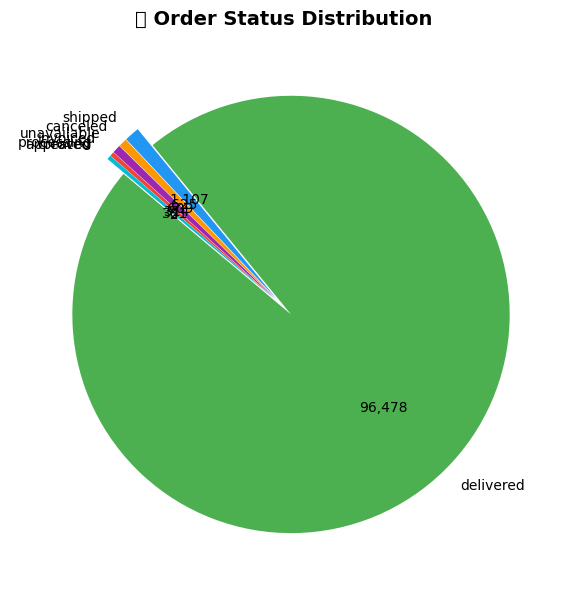

✅ Chart saved!


In [369]:
import matplotlib.pyplot as plt

status_counts = orders.groupBy('order_status') \
                      .count() \
                      .orderBy(f.desc('count')) \
                      .toPandas()

fig, ax = plt.subplots(figsize=(8, 6))

# Custom function to show actual numbers instead of percentage
def show_count(val):
    # val is the percentage — we convert it back to the actual count
    actual = int(round(val / 100 * status_counts['count'].sum()))
    return f'{actual:,}'   # :, adds comma separator e.g. 96,478

ax.pie(
    status_counts['count'],
    labels=status_counts['order_status'],
    autopct=show_count,               # ← use our function here
    startangle=140,
    explode=[0.05] * len(status_counts),
    colors=['#4CAF50','#2196F3','#FF9800',
            '#9C27B0','#f44336','#00BCD4',
            '#795548','#607D8B'][:len(status_counts)]
)

ax.set_title('📦 Order Status Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/order_status_pie.png', dpi=150)
plt.show()
print('✅ Chart saved!')

In [370]:
#Let's check for null values 

orders.select([f.count(f.when(f.col(c).isNull(),c)).alias(c)
              for c in orders.columns
              ]).show()

+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+
|order_id|customer_id|order_status|order_purchase_timestamp|order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+
|       0|          0|           0|                       0|              160|                        1783|                         2965|                            0|
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+



In [371]:
#Lets's look at the items table
items.show(5)

+--------------------+-------------+--------------------+--------------------+-------------------+-----+-------------+
|            order_id|order_item_id|          product_id|           seller_id|shipping_limit_date|price|freight_value|
+--------------------+-------------+--------------------+--------------------+-------------------+-----+-------------+
|00010242fe8c5a6d1...|            1|4244733e06e7ecb49...|48436dade18ac8b2b...|2017-09-19 09:45:35| 58.9|        13.29|
|00018f77f2f0320c5...|            1|e5f2d52b802189ee6...|dd7ddc04e1b6c2c61...|2017-05-03 11:05:13|239.9|        19.93|
|000229ec398224ef6...|            1|c777355d18b72b67a...|5b51032eddd242adc...|2018-01-18 14:48:30|199.0|        17.87|
|00024acbcdf0a6daa...|            1|7634da152a4610f15...|9d7a1d34a50524090...|2018-08-15 10:10:18|12.99|        12.79|
|00042b26cf59d7ce6...|            1|ac6c3623068f30de0...|df560393f3a51e745...|2017-02-13 13:57:51|199.9|        18.14|
+--------------------+-------------+------------

In [372]:
#let's look at payments table and what types are there
payments.show(5)
payments.groupBy('payment_type').count().orderBy(f.desc('count')).show()

+--------------------+------------------+------------+--------------------+-------------+
|            order_id|payment_sequential|payment_type|payment_installments|payment_value|
+--------------------+------------------+------------+--------------------+-------------+
|b81ef226f3fe1789b...|                 1| credit_card|                   8|        99.33|
|a9810da82917af2d9...|                 1| credit_card|                   1|        24.39|
|25e8ea4e93396b6fa...|                 1| credit_card|                   1|        65.71|
|ba78997921bbcdc13...|                 1| credit_card|                   8|       107.78|
|42fdf880ba16b47b5...|                 1| credit_card|                   2|       128.45|
+--------------------+------------------+------------+--------------------+-------------+
only showing top 5 rows
+------------+-----+
|payment_type|count|
+------------+-----+
| credit_card|76795|
|      boleto|19784|
|     voucher| 5775|
|  debit_card| 1529|
| not_defined|    3

In [373]:
#only the important rows in which the order status is delivered because that is having most
#number of rows and also this only contributes more to the business
orders=orders.filter(f.col('order_status')=='delivered')
orders.count()


96478

In [374]:
#Parsing the date strings into proper format because we are going to use them in future
orders=orders.withColumn('order_purchase_timestamp',f.to_timestamp('order_purchase_timestamp'))
orders = orders.withColumn('order_delivered_customer_date',
                f.to_timestamp('order_delivered_customer_date'))

orders = orders.withColumn('order_estimated_delivery_date',
                f.to_timestamp('order_estimated_delivery_date'))

orders.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



In [375]:
#extracting year, month, quarter, day of the week
orders = orders.withColumn('order_year',
                f.year('order_purchase_timestamp'))

orders = orders.withColumn('order_month',
                f.month('order_purchase_timestamp'))

orders = orders.withColumn('order_quarter',
                f.quarter('order_purchase_timestamp'))

orders = orders.withColumn('order_day_of_week',
                f.date_format('order_purchase_timestamp', 'E'))

orders.select('order_id', 'order_year', 'order_month',
              'order_quarter', 'order_day_of_week').show(5)

+--------------------+----------+-----------+-------------+-----------------+
|            order_id|order_year|order_month|order_quarter|order_day_of_week|
+--------------------+----------+-----------+-------------+-----------------+
|e481f51cbdc54678b...|      2017|         10|            4|              Mon|
|53cdb2fc8bc7dce0b...|      2018|          7|            3|              Tue|
|47770eb9100c2d0c4...|      2018|          8|            3|              Wed|
|949d5b44dbf5de918...|      2017|         11|            4|              Sat|
|ad21c59c0840e6cb8...|      2018|          2|            1|              Tue|
+--------------------+----------+-----------+-------------+-----------------+
only showing top 5 rows


In [376]:
#let's now calculate the delivery days
orders=orders.withColumn('delivery_days',f.datediff(f.col('order_delivered_customer_date'),f.col('order_purchase_timestamp')))
#calculating the estimated delivery days
orders=orders.withColumn('estimated_days',f.datediff(f.col('order_estimated_delivery_date'),f.col('order_purchase_timestamp')))
#checking if the order delivery was late and based on that we will put true or false in
#a new column
orders=orders.withColumn('is_late',f.col('delivery_days')>f.col('estimated_days'))

In [377]:
#Now we categories the delivery based on the delivery speed
orders=orders.withColumn('delivery_speed',
                        f.when(f.col('delivery_days')<=7,'Express')
                         .when(f.col('delivery_days')<=15,'Standard')
                         .when(f.col('delivery_days')<=30,'Slow')
                         .otherwise('Very Slow')
                        )

#dropping rows where delivery date is null or days <= 0

orders=orders.filter(f.col('order_delivered_customer_date').isNotNull())
orders=orders.filter(f.col('delivery_days')>0)

print(f'Clean orders: {orders.count():,} rows')
orders.select('order_id', 'delivery_days',
              'is_late', 'delivery_speed').show(5)

Clean orders: 96,469 rows
+--------------------+-------------+-------+--------------+
|            order_id|delivery_days|is_late|delivery_speed|
+--------------------+-------------+-------+--------------+
|e481f51cbdc54678b...|            8|  false|      Standard|
|53cdb2fc8bc7dce0b...|           14|  false|      Standard|
|47770eb9100c2d0c4...|            9|  false|      Standard|
|949d5b44dbf5de918...|           14|  false|      Standard|
|ad21c59c0840e6cb8...|            3|  false|       Express|
+--------------------+-------------+-------+--------------+
only showing top 5 rows


Now we are going to clean the items table

In [378]:
#removing rows with null values in the key columns
items=items.dropna(subset=['order_id','product_id','price'])
#removing items with price<=0
items=items.filter(f.col('price')>0)
#the items total value is actually price+freight_value so we will create a new column where
#we will keep the total price
items=items.withColumn('total_item_value',f.round(f.col('price')+f.col('freight_value'),2))

print(items.count())
items.show(5)

112650
+--------------------+-------------+--------------------+--------------------+-------------------+-----+-------------+----------------+
|            order_id|order_item_id|          product_id|           seller_id|shipping_limit_date|price|freight_value|total_item_value|
+--------------------+-------------+--------------------+--------------------+-------------------+-----+-------------+----------------+
|00010242fe8c5a6d1...|            1|4244733e06e7ecb49...|48436dade18ac8b2b...|2017-09-19 09:45:35| 58.9|        13.29|           72.19|
|00018f77f2f0320c5...|            1|e5f2d52b802189ee6...|dd7ddc04e1b6c2c61...|2017-05-03 11:05:13|239.9|        19.93|          259.83|
|000229ec398224ef6...|            1|c777355d18b72b67a...|5b51032eddd242adc...|2018-01-18 14:48:30|199.0|        17.87|          216.87|
|00024acbcdf0a6daa...|            1|7634da152a4610f15...|9d7a1d34a50524090...|2018-08-15 10:10:18|12.99|        12.79|           25.78|
|00042b26cf59d7ce6...|            1|ac6c3

In [379]:
cat_names.show(5)

+---------------------+-----------------------------+
|product_category_name|product_category_name_english|
+---------------------+-----------------------------+
|         beleza_saude|                health_beauty|
| informatica_acess...|         computers_accesso...|
|           automotivo|                         auto|
|      cama_mesa_banho|               bed_bath_table|
|     moveis_decoracao|              furniture_decor|
+---------------------+-----------------------------+
only showing top 5 rows


In [380]:
products.show(5)

+--------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|          product_id|product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|1e9e8ef04dbcff454...|           perfumaria|                 40|                       287|                 1|             225|               16|               10|              14|
|3aa071139cb16b67c...|                artes|                 44|                       276|                 1|            1000|               30|               18|              20|
|96bd76ec8810374ed...|        esporte_lazer|                 46|                       250|    

In [381]:
#cat_names is small table so we want to join it with products table(broadcasting)
products=products.join(f.broadcast(cat_names),on='product_category_name',how='left')

#renaming to something shorter product_category_name_english-->category

products=products.withColumnRenamed('product_category_name_english','category')

#fill null values with unknown
products=products.fillna('unknown',subset=['category'])

#keeping only the columns we need
products=products.select('product_id','category','product_weight_g')


print(f'Clean products: {products.count():,} rows')
products.show(5)

Clean products: 32,951 rows
+--------------------+--------------+----------------+
|          product_id|      category|product_weight_g|
+--------------------+--------------+----------------+
|1e9e8ef04dbcff454...|     perfumery|             225|
|3aa071139cb16b67c...|           art|            1000|
|96bd76ec8810374ed...|sports_leisure|             154|
|cef67bcfe19066a93...|          baby|             371|
|9dc1a7de274444849...|    housewares|             625|
+--------------------+--------------+----------------+
only showing top 5 rows


In [382]:
#lets look at the customer table
customers.show(5)

+--------------------+--------------------+------------------------+--------------------+--------------+
|         customer_id|  customer_unique_id|customer_zip_code_prefix|       customer_city|customer_state|
+--------------------+--------------------+------------------------+--------------------+--------------+
|06b8999e2fba1a1fb...|861eff4711a542e4b...|                   14409|              franca|            SP|
|18955e83d337fd6b2...|290c77bc529b7ac93...|                    9790|sao bernardo do c...|            SP|
|4e7b3e00288586ebd...|060e732b5b29e8181...|                    1151|           sao paulo|            SP|
|b2b6027bc5c5109e5...|259dac757896d24d7...|                    8775|     mogi das cruzes|            SP|
|4f2d8ab171c80ec83...|345ecd01c38d18a90...|                   13056|            campinas|            SP|
+--------------------+--------------------+------------------------+--------------------+--------------+
only showing top 5 rows


In [383]:
#fix city names to proper case(mumbai-Mumbai)
customers=customers.withColumn('customer_city',f.initcap('customer_city'))
#dropping rows with null customer_id, we are using subset because we want to remove only
#rows which contains customer_id null
customers=customers.dropna(subset=['customer_id'])


print(f'Clean customers: {customers.count():,} rows')
customers.show(5)



Clean customers: 99,441 rows
+--------------------+--------------------+------------------------+--------------------+--------------+
|         customer_id|  customer_unique_id|customer_zip_code_prefix|       customer_city|customer_state|
+--------------------+--------------------+------------------------+--------------------+--------------+
|06b8999e2fba1a1fb...|861eff4711a542e4b...|                   14409|              Franca|            SP|
|18955e83d337fd6b2...|290c77bc529b7ac93...|                    9790|Sao Bernardo Do C...|            SP|
|4e7b3e00288586ebd...|060e732b5b29e8181...|                    1151|           Sao Paulo|            SP|
|b2b6027bc5c5109e5...|259dac757896d24d7...|                    8775|     Mogi Das Cruzes|            SP|
|4f2d8ab171c80ec83...|345ecd01c38d18a90...|                   13056|            Campinas|            SP|
+--------------------+--------------------+------------------------+--------------------+--------------+
only showing top 5 rows


In [384]:
#Now lets clean the payments table
#payments.show()
print(payments.count())
print(payments.select('order_id').distinct().count())

103886
99440


In [385]:
#so some orders have multiple rows due to installments so order_id is duplicated
#we are going to collapse to one row per order
payments=payments.groupBy('order_id').agg(f.round(f.sum('payment_value'),2).alias('total_payment'),
                                         f.first('payment_type').alias('payment_type'),
                                         f.max('payment_installments').alias('installments')
                                        )

print(f'Clean payments: {payments.count():,} rows')
payments.show(5)

Clean payments: 99,440 rows
+--------------------+-------------+------------+------------+
|            order_id|total_payment|payment_type|installments|
+--------------------+-------------+------------+------------+
|000229ec398224ef6...|       216.87| credit_card|           5|
|00042b26cf59d7ce6...|       218.04| credit_card|           3|
|0005f50442cb953dc...|        65.39| credit_card|           1|
|00061f2a7bc09da83...|        68.87| credit_card|           3|
|00063b381e2406b52...|        57.98| credit_card|           5|
+--------------------+-------------+------------+------------+
only showing top 5 rows


In [386]:
#Now we are going to clean the reviews table 
#keeping only the necessary data with valid order_id and review_score
reviews=reviews.filter(f.col('order_id').isNotNull())
reviews=reviews.filter(f.col('review_score').isNotNull())

#keep only columns we need
reviews=reviews.select('order_id','review_score','review_comment_message')

#One review per order
#reviews=reviews.dropDuplicates(['order_id'])

print(f'Clean reviews: {reviews.count():,} rows')
reviews.show(10)

Clean reviews: 101,782 rows
+--------------------+------------+----------------------+
|            order_id|review_score|review_comment_message|
+--------------------+------------+----------------------+
|73fc7af87114b3971...|           4|                  NULL|
|a548910a1c6147796...|           5|                  NULL|
|f9e4b658b201a9f2e...|           5|                  NULL|
|658677c97b385a9be...|           5|  Recebi bem antes ...|
|8e6bfb81e283fa7e4...|           5|  Parabéns lojas la...|
|b18dcdf73be663668...|           1|                  NULL|
|e48aa0d2dcec3a2e8...|           5|                  NULL|
|c31a859e34e3adac2...|           5|                  NULL|
|9c214ac970e842735...|           5|                  NULL|
|b9bf720beb4ab3728...|           4|  aparelho eficient...|
+--------------------+------------+----------------------+
only showing top 10 rows


In [387]:
print('=== Sample order_id values ===')
reviews.select('order_id').show(20, truncate=False)

print('=== order_id data type ===')
reviews.printSchema()

print('=== order_id min and max length ===')
reviews.select(
    f.min(f.length('order_id')).alias('min_length'),
    f.max(f.length('order_id')).alias('max_length'),
    f.avg(f.length('order_id')).alias('avg_length')
).show()

=== Sample order_id values ===
+--------------------------------+
|order_id                        |
+--------------------------------+
|73fc7af87114b39712e6da79b0a377eb|
|a548910a1c6147796b98fdf73dbeba33|
|f9e4b658b201a9f2ecdecbb34bed034b|
|658677c97b385a9be170737859d3511b|
|8e6bfb81e283fa7e4f11123a3fb894f1|
|b18dcdf73be66366873cd26c5724d1dc|
|e48aa0d2dcec3a2e87348811bcfdf22b|
|c31a859e34e3adac22f376954e19b39d|
|9c214ac970e84273583ab523dfafd09b|
|b9bf720beb4ab3728760088589c62129|
|cdf9aa68e72324eeb25c7de974696ee2|
|3d374c9e46530bb5ed4a7648915306a6|
|9d6f15f95d01e79bd1349cc208361f09|
|2eaf8e099d871cd5c22b83b5ea8f6e0e|
|d7bd0e4afdf94846eb73642b4e3e75c3|
|e51478e7e277a83743b6f9991dbfa3fb|
|0dacf04c5ad59fd5a0cc1faa07c34e39|
|ff1581e08b3011021e7c7de592ddc81e|
|70a752414a13d09cc1f2b437b914b28e|
|583174fbe37d3d5f0d6661be3aad1786|
+--------------------------------+
only showing top 20 rows
=== order_id data type ===
root
 |-- order_id: string (nullable = true)
 |-- review_score: string (nulla

In [388]:
reviews.withColumn('id_length', f.length('order_id')) \
       .filter(f.col('id_length') != 32) \
       .select('order_id', 'review_score',
               'review_comment_message', 'id_length') \
       .show(10, truncate=False)

+--------------------+-------------------+----------------------+---------+
|order_id            |review_score       |review_comment_message|id_length|
+--------------------+-------------------+----------------------+---------+
|2018-03-23 00:00:00 |2018-04-01 00:27:51|NULL                  |19       |
|2018-01-28 00:00:00 |2018-02-04 11:06:15|NULL                  |19       |
|2017-06-24 00:00:00 |2017-06-29 13:48:21|NULL                  |19       |
|90 (ESTE FOI ENTREG"|2018-01-04 00:00:00|NULL                  |20       |
|2017-08-29 00:00:00 |2017-08-29 21:06:01|NULL                  |19       |
|2017-12-16 00:00:00 |2017-12-19 23:21:17|NULL                  |19       |
|2018-05-15 00:00:00 |2018-05-16 23:41:51|NULL                  |19       |
|2017-04-06 00:00:00 |2017-04-09 18:25:12|NULL                  |19       |
| tudo ok."          |2018-04-19 00:00:00|NULL                  |10       |
|2018-03-31 00:00:00 |2018-04-03 21:11:53|NULL                  |19       |
+-----------

In [389]:
# Reload reviews fresh
reviews = spark.read.csv(
    f'{BASE}/olist_order_reviews_dataset.csv',
    header=True,
    inferSchema=True,
    quote='"',
    escape='"',
    multiLine=True
)

print(f'Raw reviews: {reviews.count():,} rows')

Raw reviews: 99,224 rows


In [390]:
# Keep ONLY rows where order_id is a valid 32 char hex string
# Regex: exactly 32 characters of a-f and 0-9
reviews = reviews.filter(
    f.col('order_id').rlike('^[a-f0-9]{32}$')
)

print(f'After hex filter: {reviews.count():,} rows')
reviews.select('order_id') \
       .withColumn('id_length', f.length('order_id')) \
       .show(5, truncate=False)

After hex filter: 99,224 rows
+--------------------------------+---------+
|order_id                        |id_length|
+--------------------------------+---------+
|73fc7af87114b39712e6da79b0a377eb|32       |
|a548910a1c6147796b98fdf73dbeba33|32       |
|f9e4b658b201a9f2ecdecbb34bed034b|32       |
|658677c97b385a9be170737859d3511b|32       |
|8e6bfb81e283fa7e4f11123a3fb894f1|32       |
+--------------------------------+---------+
only showing top 5 rows


In [391]:
# Remove nulls
reviews = reviews.filter(f.col('order_id').isNotNull())
reviews = reviews.filter(f.col('review_score').isNotNull())

# Keep only valid scores 1-5
reviews = reviews.filter(
    f.col('review_score').isin(['1','2','3','4','5'])
)

# Cast review_score to integer
reviews = reviews.withColumn('review_score',
                  f.col('review_score').cast('integer'))

# Keep only columns we need
reviews = reviews.select('order_id', 'review_score',
                          'review_comment_message')

# One review per order — now works correctly!
reviews = reviews.dropDuplicates(['order_id'])

print(f'Clean reviews: {reviews.count():,} rows')
reviews.show(10, truncate=False)

Clean reviews: 98,673 rows


+--------------------------------+------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|order_id                        |review_score|review_comment_message                                                                                                                                                            |
+--------------------------------+------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|000229ec398224ef6ca0657da4fc703e|5           |Chegou antes do prazo previsto e o produto surpreendeu pela qualidade. Muito satisfatório.                                                                                        |
|00042b26cf59d7ce69dfabb4e55b4fd9|5           |Gostei pois veio no prazo determinado .      

In [392]:
# All these checks should pass
print('=== Verification ===')

# Check 1: all order_ids exactly 32 chars
reviews.select(
    f.min(f.length('order_id')).alias('min_len'),
    f.max(f.length('order_id')).alias('max_len')
).show()
# Expected: min=32, max=32 ✅

# Check 2: only scores 1-5
reviews.groupBy('review_score') \
       .count() \
       .orderBy('review_score') \
       .show()
# Expected: only 1,2,3,4,5 ✅

# Check 3: no duplicate order_ids
total  = reviews.count()
unique = reviews.select('order_id').distinct().count()
print(f'Total rows    : {total:,}')
print(f'Unique orders : {unique:,}')
print(f'Duplicates    : {total - unique:,}')
# Expected: Duplicates = 0 ✅

=== Verification ===
+-------+-------+
|min_len|max_len|
+-------+-------+
|     32|     32|
+-------+-------+

+------------+-----+
|review_score|count|
+------------+-----+
|           1|11353|
|           2| 3133|
|           3| 8124|
|           4|19044|
|           5|57019|
+------------+-----+

Total rows    : 98,673
Unique orders : 98,673
Duplicates    : 0


In [393]:
# PROBLEM:
# The reviews CSV file had some customer comments that contained
# commas and line breaks inside the text. Since CSV files use commas
# to separate columns, Spark got confused and treated each line break
# as a new row — creating "orphan rows" with no proper order_id.
# This caused the data to shift left, so dates and timestamps ended
# up in the order_id column instead of actual order ids. When we ran
# dropDuplicates(['order_id']) on this dirty data, the garbage rows
# caused unexpected results and broke the table completely.

# SOLUTION:
# We fixed the CSV reading by adding quote='"', escape='"' and
# multiLine=True options — this tells Spark that text wrapped in
# quotes is ONE field even if it contains commas or line breaks.
# As an extra safety net we added a regex filter
# F.col('order_id').rlike('^[a-f0-9]{32}$') which keeps ONLY rows
# where order_id is a valid 32 character hex string — removing all
# garbage rows that snuck through. After both fixes, dropDuplicates
# worked perfectly and all 3 verification checks passed.

In [394]:
#Now we have cleaned everything let's join everything in the master table
orders.cache()
orders.count()
print('Orders cached')


Orders cached


In [395]:
#let's join orders+items
master=orders.join(items,on='order_id',how='inner')
print(f'After orders + items: {master.count():,} rows')



After orders + items: 110,188 rows


In [396]:
# Join 2: + products
master = master.join(products, on='product_id', how='left')
print(f'After + products: {master.count():,} rows')

After + products: 110,188 rows


In [397]:
# Join 3: + customers
master = master.join(customers, on='customer_id', how='left')
print(f'After + customers: {master.count():,} rows')

After + customers: 110,188 rows


In [398]:
# Join 4: + payments (broadcast — small table)
master = master.join(f.broadcast(payments),
                     on='order_id', how='left')
print(f'After + payments: {master.count():,} rows')

After + payments: 110,188 rows


In [399]:
# Join 5: + reviews
master = master.join(reviews, on='order_id', how='left')
print(f'After + reviews: {master.count():,} rows')
print(f'Total columns  : {len(master.columns)}')
master.printSchema()

After + reviews: 110,188 rows
Total columns  : 34
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- order_quarter: integer (nullable = true)
 |-- order_day_of_week: string (nullable = true)
 |-- delivery_days: integer (nullable = true)
 |-- estimated_days: integer (nullable = true)
 |-- is_late: boolean (nullable = true)
 |-- delivery_speed: string (nullable = false)
 |-- order_item_id: integer (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date:

In [400]:
# Preview the master table
master.select(
    'order_id', 'customer_id', 'category',
    'price', 'delivery_days', 'customer_state',
    'payment_type', 'review_score'
).show(5, truncate=False)

+--------------------------------+--------------------------------+------------------------+-----+-------------+--------------+------------+------------+
|order_id                        |customer_id                     |category                |price|delivery_days|customer_state|payment_type|review_score|
+--------------------------------+--------------------------------+------------------------+-----+-------------+--------------+------------+------------+
|001021efaa8636c29475e7734483457d|2dfbf74859104caf100df3720a1d833d|fashion_bags_accessories|49.0 |9            |PR            |credit_card |4           |
|00130c0eee84a3d909e75bc08c5c3ca1|47d656c08a282ec5ab4c1f18303a3a30|food                    |27.9 |2            |SP            |boleto      |5           |
|0020a222f55eb79a372d0efee3cca688|0c45155afd8ff99622c40824057f9b34|furniture_decor         |29.99|9            |RJ            |credit_card |5           |
|004345d16a1ab2c21962992c721c8643|3b723b649feb48f3cfbb9c728efb3d7d|houseware

In [401]:
# Cache master — used for all analytics
master.cache()
master.count()
print('✅ Master table cached')

# Register as SQL view
master.createOrReplaceTempView('master')
print('✅ Registered as SQL view')

✅ Master table cached
✅ Registered as SQL view


In [402]:
#we are going to find top categories by revenue
top_categories=master.groupBy('category').agg(
    f.count('order_id').alias('total_orders'),
    f.round(f.sum('price'),2).alias('total_revenue'),
    f.round(f.avg('price'),2).alias('avg_order_value'),
    f.round(f.avg('review_score'),2).alias('avg_review_score')
).orderBy(f.desc('total_revenue'))

print('Top 10 Categories by Revenue:')
top_categories.show(10, truncate=False)

Top 10 Categories by Revenue:
+---------------------+------------+-------------+---------------+----------------+
|category             |total_orders|total_revenue|avg_order_value|avg_review_score|
+---------------------+------------+-------------+---------------+----------------+
|health_beauty        |9465        |1233131.72   |130.28         |4.19            |
|watches_gifts        |5857        |1165898.98   |199.06         |4.07            |
|bed_bath_table       |10953       |1023434.76   |93.44          |3.92            |
|sports_leisure       |8430        |954673.55    |113.25         |4.16            |
|computers_accessories|7643        |888613.62    |116.27         |3.99            |
|furniture_decor      |8160        |711927.69    |87.25          |3.96            |
|housewares           |6795        |615628.69    |90.6           |4.11            |
|cool_stuff           |3718        |610204.1     |164.12         |4.19            |
|auto                 |4139        |578849.35 

In [403]:
#Monthly revenue trend
monthly_revenue=master.groupBy('order_year','order_month').agg(
    f.countDistinct('order_id').alias('total_orders'),
    f.round(f.sum('price'),2).alias('monthly_revenue'),
    f.round(f.avg('price'),2).alias('avg_order_value'),
    f.round(f.avg('delivery_days'),1).alias('avg_delivery_days')
).orderBy('order_year','order_month')
print('Monthly Revenue Trend:')
monthly_revenue.show(24)

Monthly Revenue Trend:
+----------+-----------+------------+---------------+---------------+-----------------+
|order_year|order_month|total_orders|monthly_revenue|avg_order_value|avg_delivery_days|
+----------+-----------+------------+---------------+---------------+-----------------+
|      2016|          9|           1|         134.97|          44.99|             55.0|
|      2016|         10|         265|       40325.11|         128.83|             19.6|
|      2016|         12|           1|           10.9|           10.9|              5.0|
|      2017|          1|         750|      111798.36|         122.45|             12.8|
|      2017|          2|        1653|       234223.4|         126.06|             13.3|
|      2017|          3|        2546|      359198.85|         123.99|             13.1|
|      2017|          4|        2303|      340669.68|         132.61|             14.9|
|      2017|          5|        3545|      489159.25|          122.2|             11.6|
|      20

In [404]:
#now we will add month over month growth using window function\
time_window=Window.orderBy('order_year','order_month')

monthly_revenue=monthly_revenue.withColumn('prev_month_revenue',f.lag('monthly_revenue',1).over(time_window))\
.withColumn('mom_growth_pct',f.round(
    (f.col('monthly_revenue') - f.col('prev_month_revenue'))
    * 100 / f.col('prev_month_revenue'),
2))


#add cumulative revenue
running_window=Window.orderBy('order_year','order_month').rowsBetween(Window.unboundedPreceding, Window.currentRow)

monthly_revenue=monthly_revenue.withColumn('cumulative_revenue',f.round(f.sum('monthly_revenue').over(running_window),2))

print('Monthly Revenue with Growth %:')
monthly_revenue.show(24)

Monthly Revenue with Growth %:
+----------+-----------+------------+---------------+---------------+-----------------+------------------+--------------+------------------+
|order_year|order_month|total_orders|monthly_revenue|avg_order_value|avg_delivery_days|prev_month_revenue|mom_growth_pct|cumulative_revenue|
+----------+-----------+------------+---------------+---------------+-----------------+------------------+--------------+------------------+
|      2016|          9|           1|         134.97|          44.99|             55.0|              NULL|          NULL|            134.97|
|      2016|         10|         265|       40325.11|         128.83|             19.6|            134.97|      29777.09|          40460.08|
|      2016|         12|           1|           10.9|           10.9|              5.0|          40325.11|        -99.97|          40470.98|
|      2017|          1|         750|      111798.36|         122.45|             12.8|              10.9|    1025573.03|  

In [405]:
#delivery performance by state
delivery_by_state=master.filter(f.col('delivery_days').isNotNull())\
.groupBy('customer_state')\
.agg(
    f.count('order_id').alias('total_orders'),
    f.round(f.avg('delivery_days'),1).alias('avg_delivery_days'),
    f.round(f.min('delivery_days'),0).alias('min_delivery_days'),
    f.round(f.max('delivery_days'),0).alias('max_delivery_days'),
    f.sum(f.when(f.col('is_late')==True,1).otherwise(0)).alias('late_orders'),
    f.round(f.avg('review_score'),2).alias('avg_review_score')).orderBy('avg_delivery_days')
 

delivery_by_state=delivery_by_state.withColumn('late_pct',f.round(f.col('late_orders')*100/f.col('total_orders'),2))

print('Delivery Performance by State:')
delivery_by_state.show(30)

Delivery Performance by State:
+--------------+------------+-----------------+-----------------+-----------------+-----------+----------------+--------+
|customer_state|total_orders|avg_delivery_days|min_delivery_days|max_delivery_days|late_orders|avg_review_score|late_pct|
+--------------+------------+-----------------+-----------------+-----------------+-----------+----------------+--------+
|            SP|       46441|              8.7|                1|              191|       2043|            4.18|     4.4|
|            PR|        5649|             11.9|                1|               98|        219|            4.15|    3.88|
|            MG|       12916|             11.9|                1|              188|        565|            4.12|    4.37|
|            DF|        2355|             12.9|                1|               69|        141|            4.06|    5.99|
|            SC|        4097|             14.9|                2|               98|        335|            4.05|   

In [406]:
#Now lets find the payment distribution
payment_dist=master.filter(f.col('payment_type').isNotNull())\
.groupBy('payment_type').agg(
    f.countDistinct('order_id').alias('total_orders'),
    f.round(f.sum('total_payment'),2).alias('total_revenue'),
    f.round(f.avg('total_payment'),2).alias('avg_payment'),
    f.round(f.avg('installments'),1).alias('avg_installments')
).orderBy(f.desc('total_orders'))

total_orders_count=master.select(f.countDistinct('order_id')).collect()[0][0]

payment_dist=payment_dist.withColumn('pctg_of_orders',f.round(f.col('total_orders')*100/total_orders_count,2))

print('Payment Method Distribution:')
payment_dist.show()

Payment Method Distribution:
+------------+------------+-------------+-----------+----------------+--------------+
|payment_type|total_orders|total_revenue|avg_payment|avg_installments|pctg_of_orders|
+------------+------------+-------------+-----------+----------------+--------------+
| credit_card|       73212|1.521021175E7|      182.5|             3.6|         75.89|
|      boleto|       19191|   3943080.78|     176.33|             1.0|         19.89|
|     voucher|        2582|    374810.52|     132.49|             1.5|          2.68|
|  debit_card|        1483|    246323.27|      149.2|             1.0|          1.54|
+------------+------------+-------------+-----------+----------------+--------------+



In [407]:
# Find customer trends
customer_orders = master \
    .groupBy('customer_unique_id',
             'customer_state',        # ← fixed typo (custonmer → customer)
             'customer_city') \
    .agg(
        f.countDistinct('order_id').alias('num_orders'),
        f.round(f.sum('price'), 2).alias('lifetime_value'),
        f.round(f.avg('price'), 2).alias('avg_order_value'),
        f.round(f.avg('review_score'), 2).alias('avg_review_score'),
        f.round(f.avg('delivery_days'), 1).alias('avg_delivery_days')
    )

# Segment by order count
customer_orders = customer_orders \
    .withColumn('customer_segment',
                f.when(f.col('num_orders') >= 5, 'Champion')
                 .when(f.col('num_orders') >= 3, 'Loyal')
                 .when(f.col('num_orders') >= 2, 'Returning')
                 .otherwise('One-Time'))

# Segment by lifetime value
customer_orders = customer_orders \
    .withColumn('value_segment',
                f.when(f.col('lifetime_value') >= 1000, 'High Value')
                 .when(f.col('lifetime_value') >= 300,  'Mid Value')
                 .otherwise('Low Value'))

print('Customer Segment Distribution:')
customer_orders \
    .groupBy('customer_segment') \
    .count() \
    .orderBy(f.desc('count')) \
    .show()

print('Top 10 customers by lifetime value:')
customer_orders \
    .orderBy(f.desc('lifetime_value')) \
    .show(10)


Customer Segment Distribution:
+----------------+-----+
|customer_segment|count|
+----------------+-----+
|        One-Time|90763|
|       Returning| 2480|
|           Loyal|  200|
|        Champion|   19|
+----------------+-----+

Top 10 customers by lifetime value:
+--------------------+--------------+--------------+----------+--------------+---------------+----------------+-----------------+----------------+-------------+
|  customer_unique_id|customer_state| customer_city|num_orders|lifetime_value|avg_order_value|avg_review_score|avg_delivery_days|customer_segment|value_segment|
+--------------------+--------------+--------------+----------+--------------+---------------+----------------+-----------------+----------------+-------------+
|0a0a92112bd4c708c...|            RJ|Rio De Janeiro|         1|       13440.0|         1680.0|             1.0|             18.0|        One-Time|   High Value|
|da122df9eeddfedc1...|            RJ|      Araruama|         2|        7388.0|         3

In [408]:
# Rank products by price within each category
category_window = Window \
    .partitionBy('category') \
    .orderBy(f.desc('price'))

products_ranked = master \
    .select('category', 'product_id', 'price') \
    .withColumn('rank', f.rank().over(category_window))

print('Top Product per Category:')
products_ranked \
    .filter(f.col('rank') == 1) \
    .orderBy('category') \
    .show(20, truncate=False)

Top Product per Category:
+--------------------------+--------------------------------+-------+----+
|category                  |product_id                      |price  |rank|
+--------------------------+--------------------------------+-------+----+
|agro_industry_and_commerce|2b69866f22de8dad69c976771daba91c|2990.0 |1   |
|air_conditioning          |a1d54bd2293d947527d70e04dbe2a93e|1599.0 |1   |
|art                       |1bdf5e6731585cf01aa8169c7028d6ad|6499.0 |1   |
|arts_and_craftmanship     |6bb18295cc019bf3b6dc7c773411d530|289.49 |1   |
|audio                     |9bfc55df037ce3ac01bfd84781adf7e5|598.99 |1   |
|audio                     |9bfc55df037ce3ac01bfd84781adf7e5|598.99 |1   |
|audio                     |9bfc55df037ce3ac01bfd84781adf7e5|598.99 |1   |
|audio                     |9bfc55df037ce3ac01bfd84781adf7e5|598.99 |1   |
|audio                     |9bfc55df037ce3ac01bfd84781adf7e5|598.99 |1   |
|audio                     |9bfc55df037ce3ac01bfd84781adf7e5|598.99 |1   |

In [409]:
#we will do some spark sql analytics
print('Top 5 states by revenue (SQL):')
spark.sql("""
SELECT customer_state,
       COUNT(DISTINCT order_id) AS total_orders,
       ROUND(SUM(price),2) AS total_revenue,
       ROUND(AVG(delivery_days),1) AS avg_delivery_days
FROM master
GROUP BY customer_state
ORDER BY total_revenue DESC
LIMIT 5

""").show()

Top 5 states by revenue (SQL):
+--------------+------------+-------------+-----------------+
|customer_state|total_orders|total_revenue|avg_delivery_days|
+--------------+------------+-------------+-----------------+
|            SP|       40494|   5066562.98|              8.7|
|            RJ|       12349|   1759311.14|             15.1|
|            MG|       11354|   1552481.83|             11.9|
|            RS|        5344|    728718.47|             15.1|
|            PR|        4923|    666063.51|             11.9|
+--------------+------------+-------------+-----------------+



In [410]:
print('Best month per state (SQL CTE + Window):')
spark.sql("""
    WITH monthly_state AS (
        SELECT customer_state,
               order_year,
               order_month,
               ROUND(SUM(price), 2) AS revenue
        FROM   master
        GROUP  BY customer_state, order_year, order_month
    ),
    ranked AS (
        SELECT *,
               RANK() OVER (
                   PARTITION BY customer_state
                   ORDER BY revenue DESC
               ) AS rank
        FROM   monthly_state
    )
    SELECT customer_state, order_year,
           order_month, revenue
    FROM   ranked
    WHERE  rank = 1
    ORDER  BY revenue DESC
    LIMIT  10
""").show()

Best month per state (SQL CTE + Window):
+--------------+----------+-----------+---------+
|customer_state|order_year|order_month|  revenue|
+--------------+----------+-----------+---------+
|            SP|      2018|          5|424628.36|
|            RJ|      2017|         11| 147782.4|
|            MG|      2017|         11|132686.09|
|            PR|      2018|          4| 65914.88|
|            RS|      2017|         11| 57463.27|
|            SC|      2018|          4| 44555.86|
|            BA|      2018|          7| 41869.01|
|            ES|      2018|          7| 30001.36|
|            DF|      2017|         11| 26406.16|
|            PE|      2018|          7| 24359.04|
+--------------+----------+-----------+---------+



In [411]:
OUT = '/kaggle/working/output'

master \
    .write.mode('overwrite') \
    .partitionBy('order_year', 'order_month') \
    .parquet(f'{OUT}/master_table')
print('✅ master_table saved')

top_categories.write.mode('overwrite') \
    .parquet(f'{OUT}/top_categories')
print('✅ top_categories saved')

monthly_revenue.write.mode('overwrite') \
    .parquet(f'{OUT}/monthly_revenue')
print('✅ monthly_revenue saved')

delivery_by_state.write.mode('overwrite') \
    .parquet(f'{OUT}/delivery_by_state')
print('✅ delivery_by_state saved')

payment_dist.write.mode('overwrite') \
    .parquet(f'{OUT}/payment_distribution')
print('✅ payment_distribution saved')

customer_orders.write.mode('overwrite') \
    .parquet(f'{OUT}/customer_segments')
print('✅ customer_segments saved')

print('All reports saved!')

✅ master_table saved
✅ top_categories saved
✅ monthly_revenue saved
✅ delivery_by_state saved
✅ payment_distribution saved


✅ customer_segments saved
All reports saved!


In [412]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Convert to Pandas for plotting
top_cats_pd = top_categories.limit(10).toPandas()
monthly_pd  = monthly_revenue.toPandas()
delivery_pd = delivery_by_state.toPandas()
payments_pd = payment_dist.toPandas()
segments_pd = customer_orders \
    .groupBy('customer_segment').count().toPandas()

# Prep data
monthly_pd['period'] = (
    monthly_pd['order_year'].astype(str) + '-' +
    monthly_pd['order_month'].astype(str).str.zfill(2)
)
monthly_pd  = monthly_pd.sort_values('period')
top_cats_pd = top_cats_pd.sort_values('total_revenue', ascending=True)
delivery_pd = delivery_pd.sort_values('avg_delivery_days',
                                      ascending=False)

print('✅ Data ready for plotting')

✅ Data ready for plotting


/tmp/ipykernel_55/359003612.py:82: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/359003612.py:83: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/dashboard.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


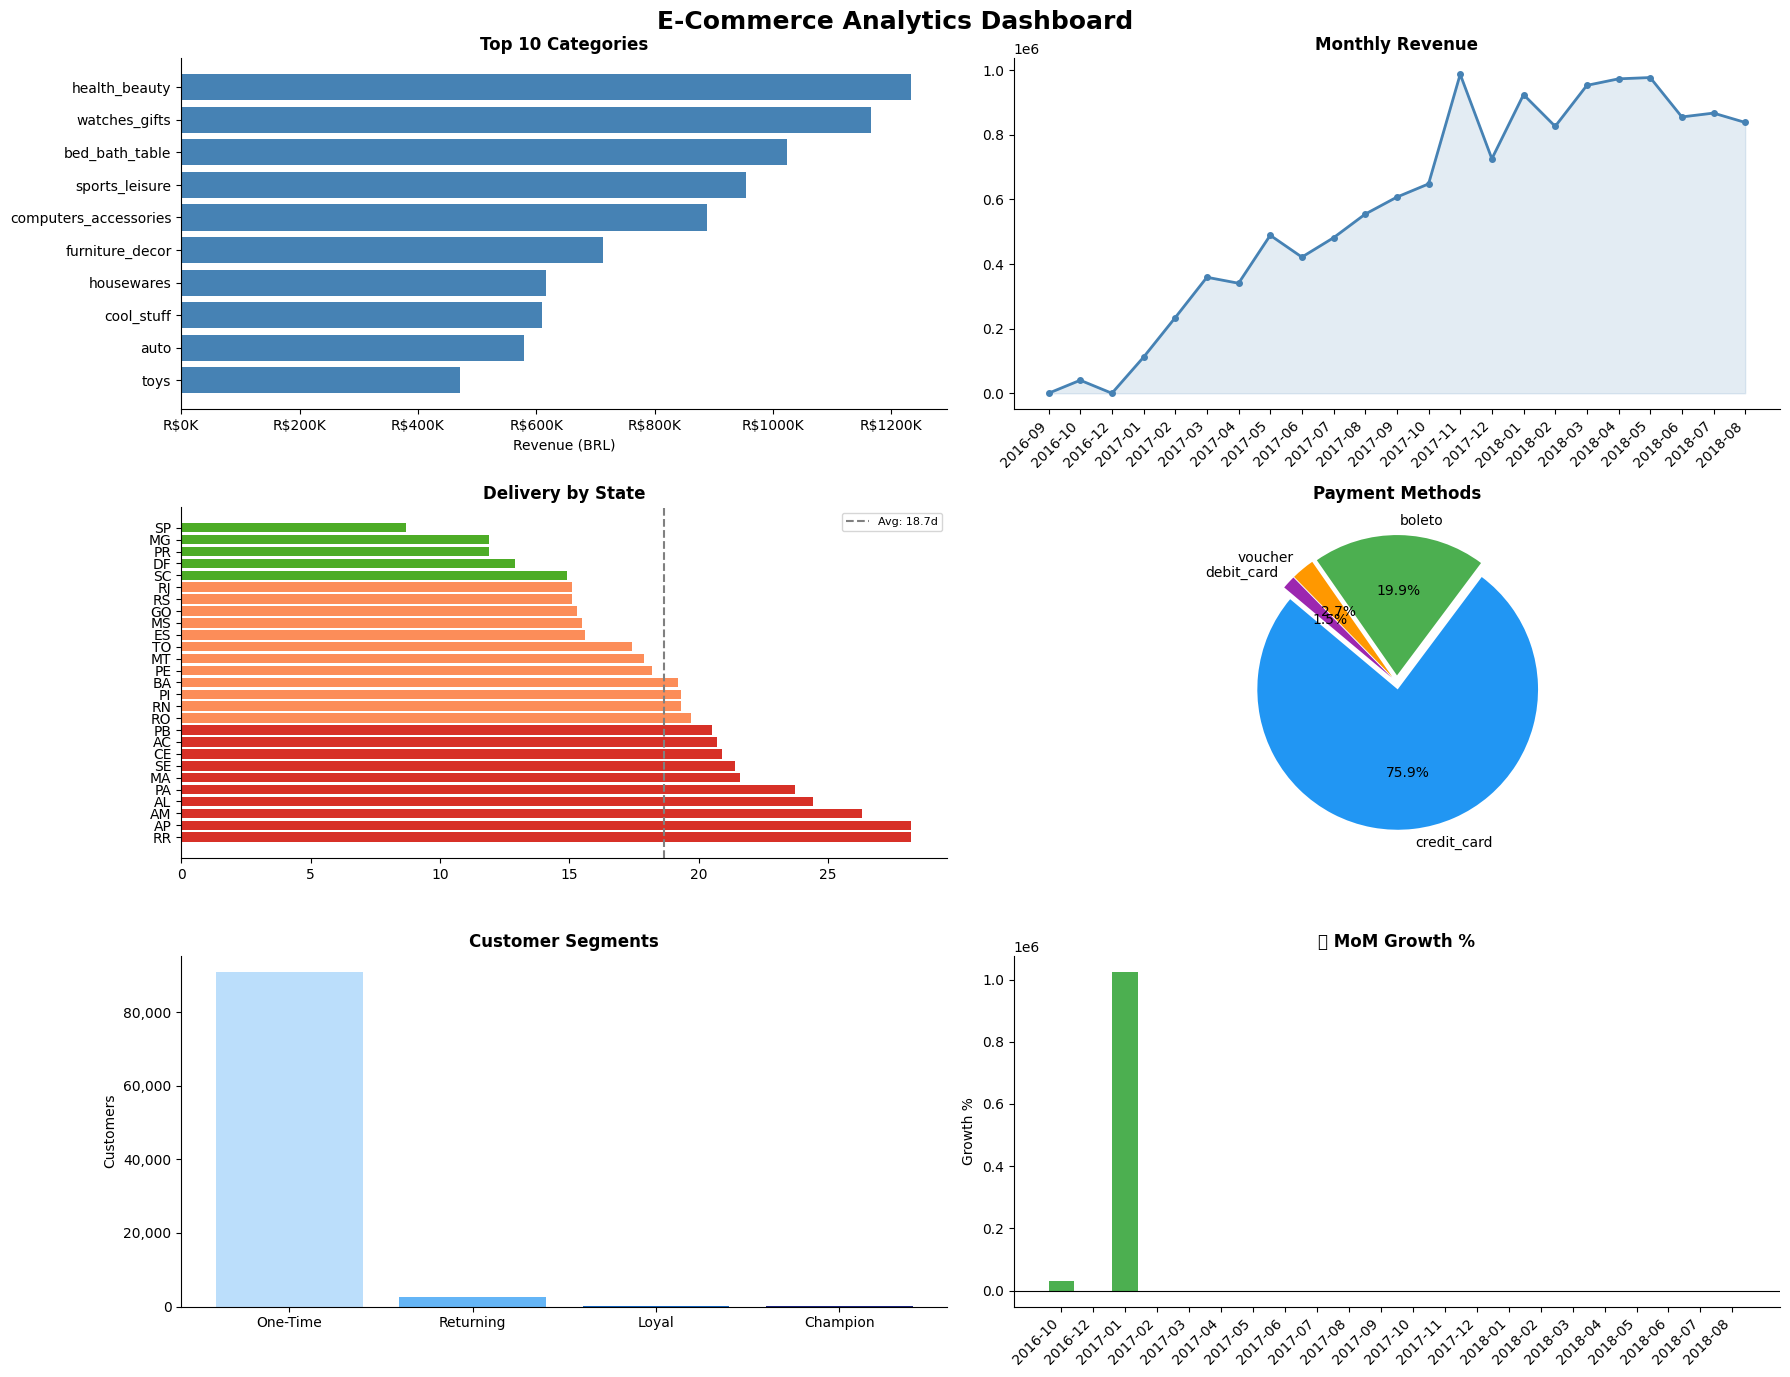

✅ Dashboard saved!


In [413]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('E-Commerce Analytics Dashboard',
             fontsize=18, fontweight='bold')

# Chart 1: Top Categories
ax1 = fig.add_subplot(3, 2, 1)
ax1.barh(top_cats_pd['category'],
         top_cats_pd['total_revenue'], color='steelblue')
ax1.set_title('Top 10 Categories', fontweight='bold')
ax1.set_xlabel('Revenue (BRL)')
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}K'))
ax1.spines[['top','right']].set_visible(False)

# Chart 2: Monthly Revenue
ax2 = fig.add_subplot(3, 2, 2)
ax2.plot(monthly_pd['period'], monthly_pd['monthly_revenue'],
         color='steelblue', linewidth=2,
         marker='o', markersize=4)
ax2.fill_between(monthly_pd['period'],
                 monthly_pd['monthly_revenue'],
                 alpha=0.15, color='steelblue')
ax2.set_title('Monthly Revenue', fontweight='bold')
plt.setp(ax2.xaxis.get_majorticklabels(),
         rotation=45, ha='right')
ax2.spines[['top','right']].set_visible(False)

# Chart 3: Delivery by State
ax3 = fig.add_subplot(3, 2, 3)
colors3 = ['#d73027' if d > 20 else
           '#fc8d59' if d > 15 else '#4dac26'
           for d in delivery_pd['avg_delivery_days']]
ax3.barh(delivery_pd['customer_state'],
         delivery_pd['avg_delivery_days'], color=colors3)
ax3.axvline(
    x=delivery_pd['avg_delivery_days'].mean(),
    color='gray', linestyle='--',
    label=f"Avg: {delivery_pd['avg_delivery_days'].mean():.1f}d")
ax3.set_title('Delivery by State', fontweight='bold')
ax3.legend(fontsize=8)
ax3.spines[['top','right']].set_visible(False)

# Chart 4: Payment Methods
ax4 = fig.add_subplot(3, 2, 4)
colors4 = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
ax4.pie(payments_pd['total_orders'],
        labels=payments_pd['payment_type'],
        autopct='%1.1f%%',
        colors=colors4[:len(payments_pd)],
        startangle=140,
        explode=[0.05]*len(payments_pd))
ax4.set_title('Payment Methods', fontweight='bold')

# Chart 5: Customer Segments
ax5 = fig.add_subplot(3, 2, 5)
seg_colors = {'Champion':'#1a237e', 'Loyal':'#1565c0',
              'Returning':'#64b5f6', 'One-Time':'#bbdefb'}
segs = segments_pd.sort_values('count', ascending=False)
ax5.bar(segs['customer_segment'], segs['count'],
        color=[seg_colors.get(s,'gray')
               for s in segs['customer_segment']])
ax5.set_title('Customer Segments', fontweight='bold')
ax5.set_ylabel('Customers')
ax5.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax5.spines[['top','right']].set_visible(False)

# Chart 6: MoM Growth
ax6 = fig.add_subplot(3, 2, 6)
growth = monthly_pd.dropna(subset=['mom_growth_pct'])
bar_colors = ['#4CAF50' if g >= 0 else '#f44336'
              for g in growth['mom_growth_pct']]
ax6.bar(growth['period'], growth['mom_growth_pct'],
        color=bar_colors)
ax6.axhline(y=0, color='black', linewidth=0.8)
ax6.set_title('📈 MoM Growth %', fontweight='bold')
ax6.set_ylabel('Growth %')
plt.setp(ax6.xaxis.get_majorticklabels(),
         rotation=45, ha='right')
ax6.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved!')

Top 20 cities by revenue:
+--------------+--------------------+------------+-------------+------------+----------------+
|customer_state|       customer_city|total_orders|total_revenue|avg_delivery|unique_customers|
+--------------+--------------------+------------+-------------+------------+----------------+
|            SP|           Sao Paulo|       17400|   1859556.83|         8.0|           14528|
|            RJ|      Rio De Janeiro|        7591|    955233.98|        14.6|            6360|
|            MG|      Belo Horizonte|        3087|    346039.04|        11.0|            2606|
|            DF|            Brasilia|        2341|    295814.72|        12.9|            2013|
|            PR|            Curitiba|        1727|    205999.33|        10.3|            1434|
|            SP|            Campinas|        1626|    184657.87|         9.6|            1363|
|            RS|        Porto Alegre|        1572|    182140.55|        15.8|            1291|
|            BA|        

/tmp/ipykernel_55/4051234034.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_pd,


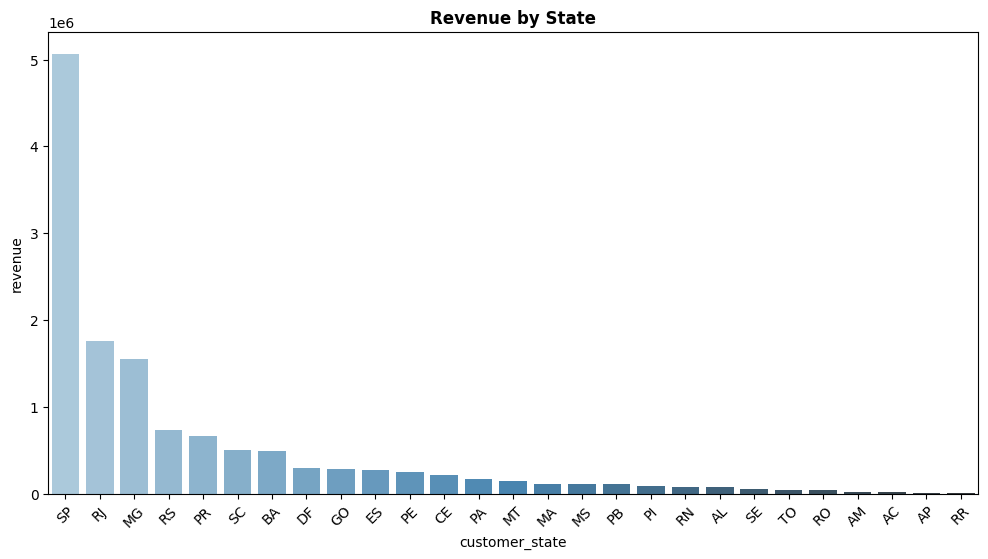

In [414]:
#GEOGRAPHIC REVENUE HEATMAP
# Code to add:
geo_analysis = master \
    .groupBy('customer_state', 'customer_city') \
    .agg(
        f.count('order_id').alias('total_orders'),
        f.round(f.sum('price'), 2).alias('total_revenue'),
        f.round(f.avg('delivery_days'), 1).alias('avg_delivery'),
        f.countDistinct('customer_unique_id').alias('unique_customers')
    ) \
    .orderBy(f.desc('total_revenue'))

# Top 20 cities
print('Top 20 cities by revenue:')
geo_analysis.show(20)

# Visualize as heatmap
import seaborn as sns
import matplotlib.pyplot as plt

state_pd = master \
    .groupBy('customer_state') \
    .agg(f.round(f.sum('price'), 2).alias('revenue')) \
    .toPandas() \
    .sort_values('revenue', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=state_pd,
            x='customer_state',
            y='revenue',
            palette='Blues_d')
plt.title('Revenue by State', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

In [415]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Calculate the numbers
total_revenue = master.agg(
    f.round(f.sum('price'), 2).alias('total_revenue')
).collect()[0]['total_revenue']

total_orders = master.agg(
    f.countDistinct('order_id').alias('total_orders')
).collect()[0]['total_orders']

print(f'Total Revenue : R${total_revenue:,.2f}')
print(f'Total Orders  : {total_orders:,}')

Total Revenue : R$13,219,908.94
Total Orders  : 96,469


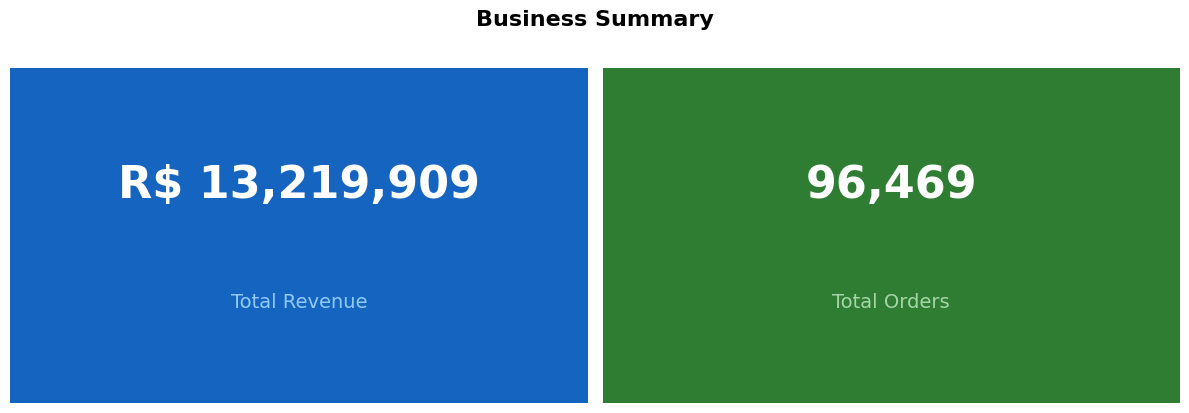

✅ Summary cards saved!


In [416]:
# Draw the two cards
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ── Card 1: Total Revenue ──────────────────────────
ax1.set_facecolor('#1565C0')
fig.patch.set_facecolor('white')

ax1.text(0.5, 0.65,
         f'R$ {total_revenue:,.0f}',
         ha='center', va='center',
         fontsize=32, fontweight='bold',
         color='white',
         transform=ax1.transAxes)

ax1.text(0.5, 0.30,
         'Total Revenue',
         ha='center', va='center',
         fontsize=14,
         color='#90CAF9',
         transform=ax1.transAxes)

ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)

# ── Card 2: Total Orders ───────────────────────────
ax2.set_facecolor('#2E7D32')

ax2.text(0.5, 0.65,
         f'{total_orders:,}',
         ha='center', va='center',
         fontsize=32, fontweight='bold',
         color='white',
         transform=ax2.transAxes)

ax2.text(0.5, 0.30,
         'Total Orders',
         ha='center', va='center',
         fontsize=14,
         color='#A5D6A7',
         transform=ax2.transAxes)

ax2.set_xticks([])
ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.suptitle('Business Summary',
             fontsize=16,
             fontweight='bold',
             y=1.02)

plt.tight_layout()
plt.savefig('/kaggle/working/summary_cards.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Summary cards saved!')
